# Notebook avançado — Árvores, Boosting e Métricas

Este notebook aprofunda a análise visual de modelos baseados em árvores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


## Gerando dataset

In [2]:
X, y = make_classification(n_samples=1200, n_features=8, n_informative=5, random_state=42)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(8)])
df['target'] = y
df.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,target
0,1.097936,-0.235339,-1.937418,0.750416,2.301444,3.837100,-2.479549,0.539402,1
1,0.227954,-0.536259,-0.010071,-0.704501,0.226131,1.497064,-0.231582,-1.282629,0
2,-1.618460,1.399618,1.093922,-1.359387,-1.519304,-1.049175,0.893494,0.769565,1
3,0.591941,1.548401,1.852616,-0.790163,-0.177628,-0.608962,-1.184543,0.138832,0
4,0.918056,-0.148882,1.949993,1.267908,0.898411,0.918940,-2.821266,-0.449107,1


## Correlação entre as variáveis

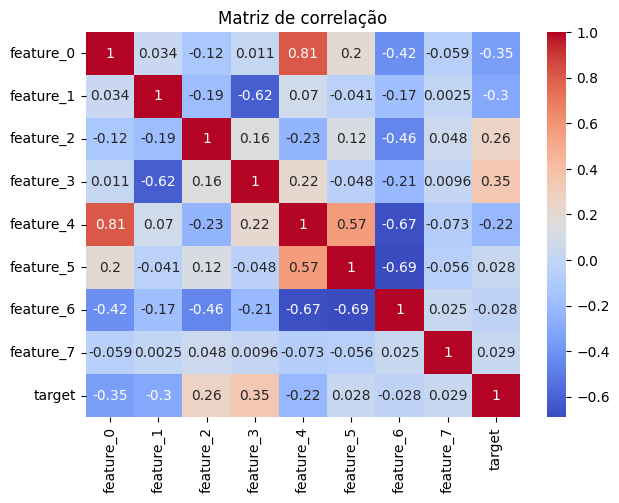

In [3]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()


**Interpretação:** correlação alta pode indicar redundância entre features. Isso pode influenciar a leitura da feature importance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Decision Tree

In [5]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)


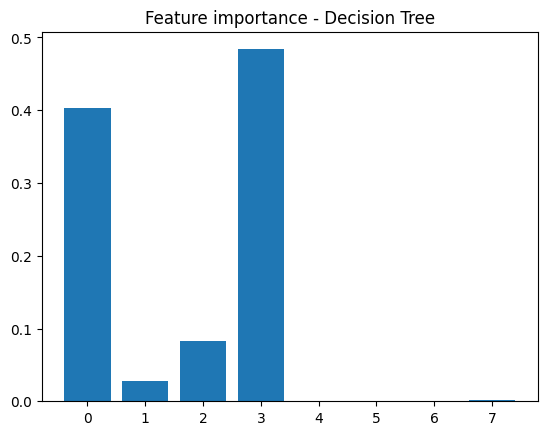

In [6]:
tree_importance = tree_model.feature_importances_
plt.bar(range(len(tree_importance)), tree_importance)
plt.title('Feature importance - Decision Tree')
plt.show()


## LightGBM

In [7]:
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)


[LightGBM] [Info] Number of positive: 422, number of negative: 418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 840, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502381 -> initscore=0.009524
[LightGBM] [Info] Start training from score 0.009524
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\mathe\Downloads\atividade_17-03\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


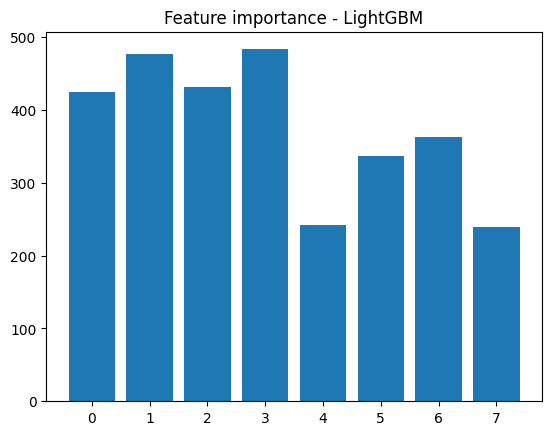

In [8]:
lgb_importance = lgb_model.feature_importances_
plt.bar(range(len(lgb_importance)), lgb_importance)
plt.title('Feature importance - LightGBM')
plt.show()


## CatBoost

In [9]:
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)


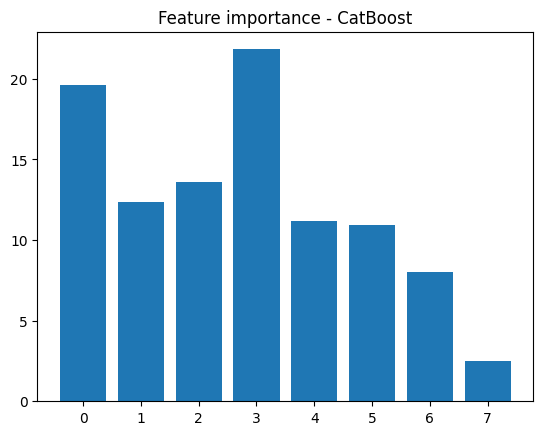

In [10]:
cat_importance = cat_model.get_feature_importance()
plt.bar(range(len(cat_importance)), cat_importance)
plt.title('Feature importance - CatBoost')
plt.show()


## Matrizes de confusão

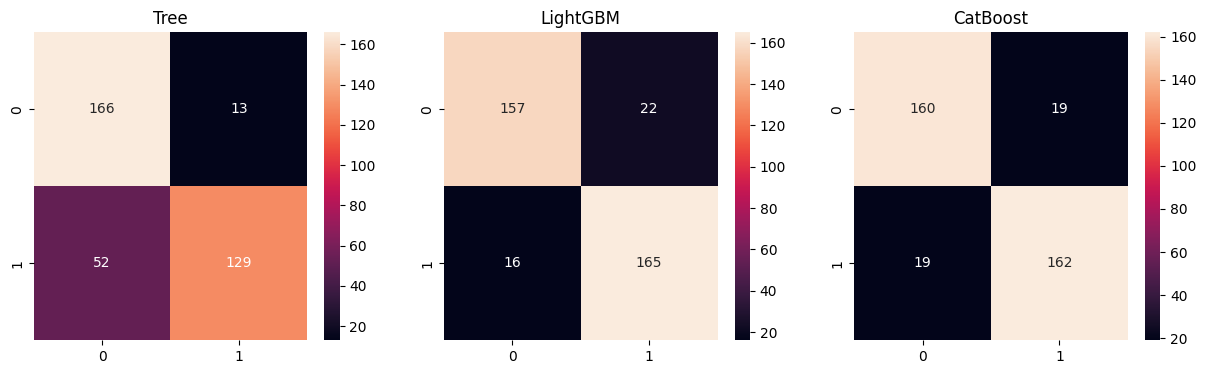

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, pred, title in zip(axes, [tree_pred, lgb_pred, cat_pred], ['Tree', 'LightGBM', 'CatBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(title)
plt.show()


## Accuracy, Precision, Recall, F1

In [12]:
print('Decision Tree')
print(classification_report(y_test, tree_pred))
print('LightGBM')
print(classification_report(y_test, lgb_pred))
print('CatBoost')
print(classification_report(y_test, cat_pred))


Decision Tree
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       179
           1       0.91      0.71      0.80       181

    accuracy                           0.82       360
   macro avg       0.83      0.82      0.82       360
weighted avg       0.84      0.82      0.82       360

LightGBM
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       179
           1       0.88      0.91      0.90       181

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360

CatBoost
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       179
           1       0.90      0.90      0.90       181

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.8

**Explicação:**
- Accuracy = total de acertos.
- Precision = confiança nas previsões positivas.
- Recall = cobertura dos positivos reais.
- F1 = equilíbrio entre precision e recall.

## Curvas ROC e AUROC

c:\Users\mathe\Downloads\atividade_17-03\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


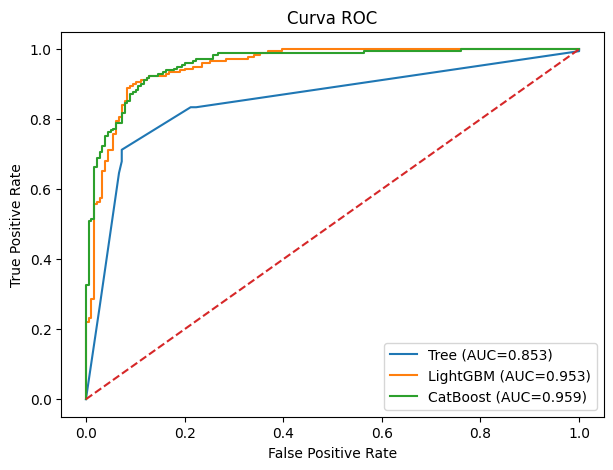

In [13]:
tree_prob = tree_model.predict_proba(X_test)[:,1]
lgb_prob = lgb_model.predict_proba(X_test)[:,1]
cat_prob = cat_model.predict_proba(X_test)[:,1]
plt.figure(figsize=(7,5))
for prob, name in [(tree_prob, 'Tree'), (lgb_prob, 'LightGBM'), (cat_prob, 'CatBoost')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


## Discussão final
Qual modelo teve melhor equilíbrio entre desempenho e interpretabilidade? Como a correlação pode influenciar a importância das features?

ANÁLISE COMPARATIVA DOS MODELOS
1. Desempenho dos modelos

O modelo de Decision Tree apresenta um desempenho variável em termos de ROC-AUC, fortemente dependente da profundidade configurada. Já o LightGBM se destaca por um melhor desempenho em generalização, enquanto o CatBoost apresenta o melhor desempenho geral, sendo também mais robusto.

2. Interpretabilidade

A Decision Tree é altamente interpretável, permitindo fácil visualização da árvore de decisão e compreensão das regras utilizadas. No entanto, possui tendência a overfitting e desempenho inferior em comparação com modelos de boosting.

Por outro lado, tanto o LightGBM quanto o CatBoost oferecem excelente desempenho e uma boa definição da importância das features. Contudo, são menos interpretáveis, funcionando como modelos do tipo “caixa-preta”, e apresentam maior complexidade para entender decisões individuais.

3. Equilíbrio entre desempenho e interpretabilidade

O modelo que apresenta o melhor equilíbrio é o CatBoost. Ele combina alto desempenho com uma interpretação razoável por meio de análise de importância de features e uso de métodos como SHAP, além de ser robusto para dados categóricos.

Como alternativa, a Decision Tree pode ser utilizada quando a interpretabilidade é um requisito crítico, aceitando-se a perda de desempenho em troca de total clareza nas decisões.

4. Influência da correlação na importância das features

A presença de correlação entre variáveis impacta diretamente a análise de importância das features.

A multicolinearidade ocorre quando features correlacionadas competem entre si, fazendo com que o modelo escolha uma em detrimento da outra, o que gera instabilidade na atribuição de importância.

Além disso, a redundância de informação faz com que features altamente correlacionadas carreguem essencialmente o mesmo conteúdo, reduzindo o ganho preditivo ao incluí-las juntas e aumentando a incerteza sobre qual delas é realmente relevante.

O impacto disso varia por modelo:

A Decision Tree tende a selecionar apenas uma das features correlacionadas.

O LightGBM pode distribuir a importância entre elas.

O CatBoost costuma ser mais estável nesse cenário.

5. Recomendações práticas

Antes da modelagem, é importante analisar a matriz de correlação para identificar relações fortes entre variáveis. Features com correlação superior a 0,9 devem ser avaliadas quanto à remoção por redundância.

Também é recomendável utilizar técnicas de seleção de features, como VIF ou SelectKBest, e sempre considerar o conhecimento de domínio em conjunto com métricas estatísticas.

Para relatórios executivos, recomenda-se o uso de Decision Tree ou métodos explicativos como SHAP. Já para maximizar o desempenho preditivo, CatBoost ou LightGBM são as melhores escolhas.

Conclusão

A escolha do modelo deve considerar três fatores principais: o contexto (se desempenho ou interpretabilidade é mais importante), as características dos dados (como a presença de correlação entre features) e o objetivo do projeto (previsão ou explicabilidade).

Para o dataset analisado, o CatBoost se mostra como a melhor opção, oferecendo um bom equilíbrio entre desempenho e interpretabilidade. No entanto, a correlação entre features impacta significativamente a análise de importância, exigindo uma avaliação cuidadosa para garantir a validade dos insights.